
# Блок 3. Продвинутый уровень. Занятие 15

# Финансовый анализ и прогнозирование

## Теория

Сегодня изучаем основы финансовой аналитики на реальном датасете.

Будем использовать открытый датасет фондового рынка S&P500:

https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv

### Описание колонок

| Колонка | Описание |
|----------|----------|
| Date | дата торгов |
| SP500 | значение индекса S&P500 |

S&P500 — один из самых известных фондовых индексов мира.

---

## Что будем делать

- загружать финансовые данные;
- строить временные ряды;
- вычислять изменения;
- строить скользящее среднее;
- делать простой прогноз;
- анализировать тренды.

---

## Практическое применение

Похожие задачи используются:

- в банках;
- инвестиционных компаниях;
- бизнес-аналитике;
- прогнозировании продаж;
- анализе прибыли компаний.

---

## Связь с дипломом

Такие методы пригодятся:

- анализ продаж;
- анализ выручки;
- анализ клиентов;
- анализ недвижимости;
- анализ тренировок;
- анализ питания.


Сначала изучите SOLVED-ноутбук, затем выполните TODO самостоятельно.

## Ячейка 1. TODO: импорт библиотек

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

assert pd is not None


## Ячейка 2. TODO: загрузите финансовый датасет

In [94]:
import random

file_path = r"..\..\data\health_fitness_dataset.csv"

df_raw = pd.read_csv(file_path)

unique_users = df_raw["participant_id"].unique()
print("Уникальных ID:", len(unique_users) )

user_id = random.choice(unique_users)
print("Выбран пользователь:", user_id)

df = df_raw[df_raw["participant_id"] == user_id].copy()

print("Размер загруженных данных:", df.shape)
display(df.head())
assert len(df) > 30, "Данных должно быть больше 30 дней"




Уникальных ID: 3000
Выбран пользователь: 729
Размер загруженных данных: (219, 23)


,participant_id,date,age,gender,height_cm,weight_kg,bmi,activity_type,duration_minutes,intensity,...,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,endurance_level,sleep_hours,stress_level,hydration_level,smoking_status,health_condition,fitness_level
167236,729,2024/1/2,44,F,165.0,52.37,19.23,HIIT,20.0,High,...,66.0,112.5,81.6,5.75,6.4,5,3.0,Never,NaN,0.11
167237,729,2024/1/5,44,F,165.0,57.43,21.09,HIIT,49.1,Low,...,66.0,112.5,81.6,5.77,6.1,8,2.3,Never,NaN,0.21
167238,729,2024/1/8,44,F,165.0,51.92,19.07,HIIT,43.7,Medium,...,66.0,112.5,81.6,5.80,8.3,3,2.9,Never,NaN,0.34
167239,729,2024/1/10,44,F,165.0,51.99,19.10,HIIT,20.6,Low,...,66.0,112.5,81.6,5.82,8.3,3,2.2,Never,NaN,0.44
167240,729,2024/1/12,44,F,165.0,50.39,18.51,Cycling,20.0,Medium,...,66.0,112.5,81.6,5.85,5.2,7,2.3,Never,NaN,0.52


## Ячейка 3. TODO: изучите структуру данных

In [95]:
print(df.shape)
print(df.columns.tolist())

df.info()


(219, 23)
['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg', 'bmi', 'activity_type', 'duration_minutes', 'intensity', 'calories_burned', 'daily_steps', 'avg_heart_rate', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'endurance_level', 'sleep_hours', 'stress_level', 'hydration_level', 'smoking_status', 'health_condition', 'fitness_level']
<class 'pandas.DataFrame'>
RangeIndex: 219 entries, 167236 to 167454
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            219 non-null    int64  
 1   date                      219 non-null    str    
 2   age                       219 non-null    int64  
 3   gender                    219 non-null    str    
 4   height_cm                 219 non-null    float64
 5   weight_kg                 219 non-null    float64
 6   bmi                       219 non-null    float64
 7   activity

## Ячейка 4. TODO: преобразуйте дату

In [109]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(
    f"Диапазон дат: {df['date'].min().strftime('%d.%m.%Y')} - {df['date'].max().strftime('%d.%m.%Y')}"
)

print(df.dtypes)

assert str(df["date"].dtype).startswith("datetime")


Диапазон дат: 02.01.2024 - 24.12.2024
participant_id                       int64
date                        datetime64[us]
age                                  int64
gender                                 str
height_cm                          float64
weight_kg                          float64
bmi                                float64
activity_type                          str
duration_minutes                   float64
intensity                              str
calories_burned                    float64
daily_steps                          int64
avg_heart_rate                       int64
resting_heart_rate                 float64
blood_pressure_systolic            float64
blood_pressure_diastolic           float64
endurance_level                    float64
sleep_hours                        float64
stress_level                         int64
hydration_level                    float64
smoking_status                         str
health_condition                       str
fitness_level   

## Ячейка 5. TODO: постройте график индекса

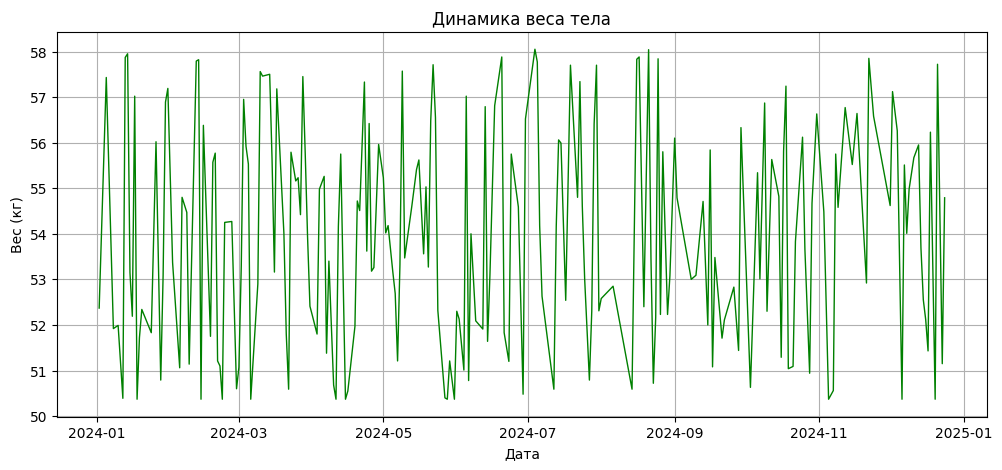

In [97]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["weight_kg"], color="green", linewidth=1)
plt.title("Динамика веса тела")
plt.xlabel("Дата")
plt.ylabel("Вес (кг)")
plt.grid(True)
plt.show()


## Ячейка 6. TODO: вычислите изменения индекса

In [98]:
df["delta_weight"] = df["weight_kg"].diff()
print("Первые строки с изменениями:")
display(df[["date", "weight_kg", "delta_weight"]].head(10))


Первые строки с изменениями:


,date,weight_kg,delta_weight
0,2024-01-02,52.37,NaN
1,2024-01-05,57.43,5.06
2,2024-01-08,51.92,-5.51
3,2024-01-10,51.99,0.07
4,2024-01-12,50.39,-1.60
5,2024-01-13,57.87,7.48
6,2024-01-14,57.95,0.08
7,2024-01-15,53.15,-4.80
8,2024-01-16,52.19,-0.96
9,2024-01-17,57.02,4.83


## Ячейка 7. TODO: создайте скользящее среднее

In [99]:
n_rolling = 14
df["ma"] = df["weight_kg"].rolling(window=n_rolling).mean()

display(df[["participant_id", "weight_kg", "ma"]].head(40))

assert "ma" in df.columns


,participant_id,weight_kg,ma
0,729,52.37,NaN
1,729,57.43,NaN
2,729,51.92,NaN
3,729,51.99,NaN
4,729,50.39,NaN
5,729,57.87,NaN
6,729,57.95,NaN
7,729,53.15,NaN
8,729,52.19,NaN
9,729,57.02,NaN


## Ячейка 8. TODO: постройте сравнительный график

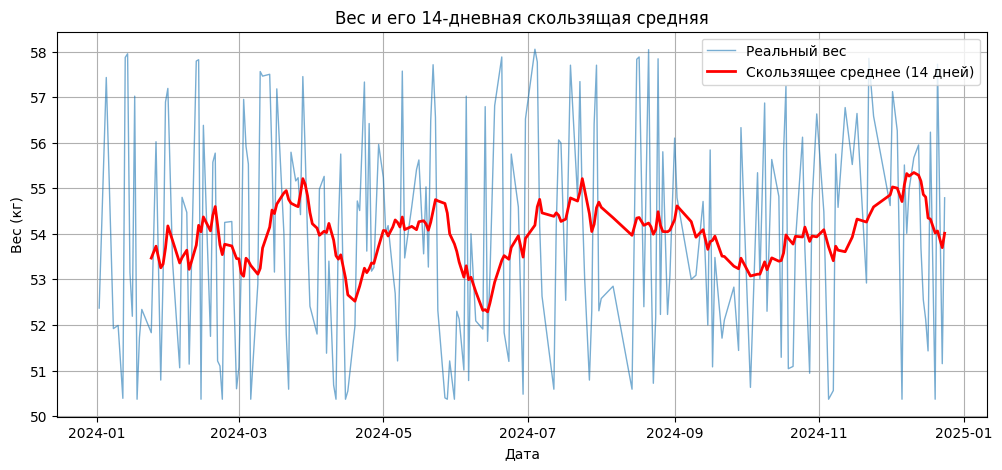

In [100]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["weight_kg"], label="Реальный вес", alpha=0.6, linewidth=1)
plt.plot(
    df["date"], df["ma"], label=f"Скользящее среднее ({n_rolling} дней)", color="red", linewidth=2
)
plt.title(f"Вес и его {n_rolling}-дневная скользящая средняя")
plt.xlabel("Дата")
plt.ylabel("Вес (кг)")
plt.legend()
plt.grid(True)
plt.show()


## Ячейка 9. TODO: сделайте простой прогноз

In [101]:
forecast = df["weight_kg"].tail(30).mean()

print("Прогноз:", forecast)

assert forecast > 0


Прогноз: 54.43966666666667


## Ячейка 10. TODO: сформируйте отчет и assert

In [102]:
report = {
    "rows": len(df),
    "min": df["weight_kg"].min(),
    "max": df["weight_kg"].max(),
    "mean": df["weight_kg"].mean(),
    "forecast": forecast,
}

for k, v in report.items():
    print(k, ":", v)

assert report["rows"] > 1


rows : 219
min : 50.37
max : 58.05
mean : 53.96237442922374
forecast : 54.43966666666667
